<a href="https://colab.research.google.com/github/2000030914/2000030914/blob/main/cp2_70_acc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [ ]:
base_path = "/content/drive/MyDrive/AnnotatedUltrasoundLiver_Dataset"
classes = ['Benign', 'Malignant', 'Normal']

In [ ]:
for cls in classes:
    path = os.path.join(base_path, cls, "image")
    print(f"{cls}: {len(os.listdir(path))} images")

Benign: 200 images
Malignant: 435 images
Normal: 100 images


In [ ]:
import pandas as pd

filepaths = []
labels = []

for label in classes:
    folder = os.path.join(base_path, label, "image")
    for file in os.listdir(folder):
        filepaths.append(os.path.join(folder, file))
        labels.append(label)

df = pd.DataFrame({
    'filename': filepaths,
    'class': labels
})

print("Total images:", len(df))

Total images: 735


In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['class'],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))

Train: 588
Validation: 147


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

Found 588 validated image filenames belonging to 3 classes.
Found 147 validated image filenames belonging to 3 classes.


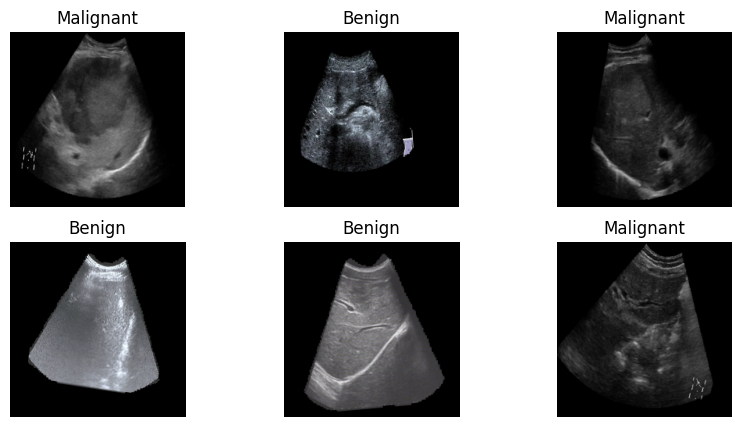

In [ ]:
images, labels_batch = next(train_generator)

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(list(train_generator.class_indices.keys())[int(labels_batch[i])])
    plt.axis('off')
plt.show()

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(3, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 244s 6s/step - accuracy: 0.4065 - loss: 1.7285 - val_accuracy: 0.5238 - val_loss: 1.0516
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5408 - loss: 1.2231 - val_accuracy: 0.6190 - val_loss: 0.8692
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.5714 - loss: 1.0568 - val_accuracy: 0.6531 - val_loss: 0.7972
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6088 - loss: 1.0349 - val_accuracy: 0.6395 - val_loss: 0.7644
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6429 - loss: 0.8930 - val_accuracy: 0.6463 - val_loss: 0.7549


In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
print("Final Validation Accuracy:", val_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 569ms/step - accuracy: 0.6803 - loss: 0.6986
Final Validation Accuracy: 0.680272102355957


In [ ]:
cnn_model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(3, activation='softmax')
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

cnn_loss, cnn_acc = cnn_model.evaluate(val_generator)
print("CNN Accuracy:", cnn_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 136s 4s/step - accuracy: 0.5714 - loss: 2.2601 - val_accuracy: 0.1429 - val_loss: 1.5643
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.6395 - loss: 0.8100 - val_accuracy: 0.1361 - val_loss: 2.4773
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.6224 - loss: 0.8476 - val_accuracy: 0.2789 - val_loss: 2.9324
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.6173 - loss: 0.7321 - val_accuracy: 0.5986 - val_loss: 3.1460
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.6327 - loss: 0.7056 - val_accuracy: 0.5986 - val_loss: 3.4433
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 566ms/step - accuracy: 0.5986 - loss: 3.4433
CNN Accuracy: 0.5986394286155701


In [ ]:
# =========================
# MOBILENETV2 MODEL
# =========================

# Load pretrained base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False

# Build model
mobilenet_model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(3, activation='softmax')
])

# Compile
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

# Evaluate
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(val_generator)

print("MobileNet Validation Accuracy:", mobilenet_acc)

Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.3810 - loss: 1.6209 - val_accuracy: 0.5714 - val_loss: 0.9158
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.4796 - loss: 1.3155 - val_accuracy: 0.6463 - val_loss: 0.8154
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.5595 - loss: 1.0410 - val_accuracy: 0.6667 - val_loss: 0.7601
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6139 - loss: 1.0292 - val_accuracy: 0.6667 - val_loss: 0.7281
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6599 - loss: 0.8843 - val_accuracy: 0.6871 - val_loss: 0.7133
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 786ms/step - accuracy: 0.6871 - loss: 0.7133
MobileNet Validation Accuracy: 0.6870748400688171


In [ ]:
# =========================
# OPTIMIZED MOBILENETV2
# =========================

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# -------------------------
# LOAD BASE MODEL
# -------------------------
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# -------------------------
# BUILD MODEL
# -------------------------
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.6),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(3, activation='softmax')
])

# -------------------------
# COMPILE (LOW LR)
# -------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------
# CLASS WEIGHTS (IMPORTANT)
# -------------------------
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['class']),
    y=train_df['class']
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# -------------------------
# TRAIN (PHASE 1)
# -------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights
)

# -------------------------
# FINE-TUNING
# -------------------------
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

# -------------------------
# RECOMPILE
# -------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------
# TRAIN (PHASE 2)
# -------------------------
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights
)

# -------------------------
# FINAL EVALUATION
# -------------------------
val_loss, val_acc = model.evaluate(val_generator)
print("Final MobileNet Accuracy:", val_acc)

Class Weights: {0: np.float64(1.225), 1: np.float64(0.5632183908045977), 2: np.float64(2.45)}
Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.3571 - loss: 1.6452 - val_accuracy: 0.5782 - val_loss: 0.9357
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.4490 - loss: 1.3667 - val_accuracy: 0.5782 - val_loss: 0.8869
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.4099 - loss: 1.4626 - val_accuracy: 0.6667 - val_loss: 0.8482
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.4711 - loss: 1.3274 - val_accuracy: 0.6667 - val_loss: 0.8216
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4881 - loss: 1.3141 - val_accuracy: 0.6599 - val_loss: 0.7965
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5136 - loss: 1.2617 - val_accuracy: 0.6871 - val_loss: 0.7822
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.5068 - loss: 1.2028 - val_accuracy: 0.6871 - val_loss: 0.7631
Epoch 8/10
37/37 ━━━━━━━

Total images: 735
Found 588 validated image filenames belonging to 3 classes.
Found 147 validated image filenames belonging to 3 classes.
Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.4983 - loss: 1.1948 - val_accuracy: 0.6531 - val_loss: 0.7915
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5595 - loss: 0.9501 - val_accuracy: 0.6735 - val_loss: 0.7130
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6293 - loss: 0.8156 - val_accuracy: 0.7007 - val_loss: 0.6821
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6361 - loss: 0.7717 - val_accuracy: 0.7075 - val_loss: 0.6716
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6616 - loss: 0.7425 - val_accuracy: 0.7007 - val_loss: 0.6739
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6667 - loss: 0.7423 - val_accuracy: 0.7211 - val_loss: 0.6719
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.6582 - loss: 0.7296 - val_accuracy: 0.6939

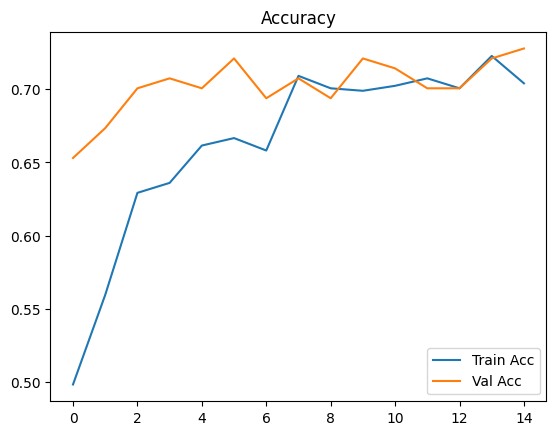

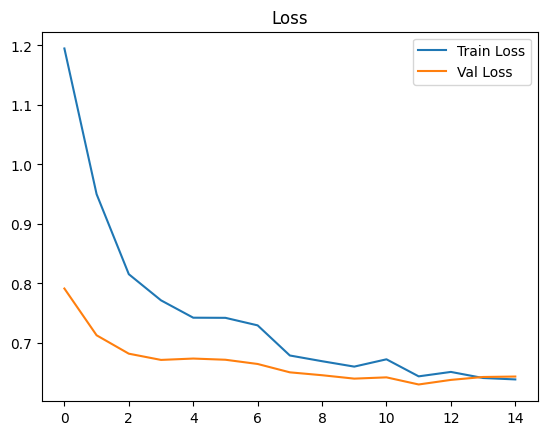

In [ ]:
# =========================
# IMPORTS
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# =========================
# DATASET PATH
# =========================
base_path = "/content/drive/MyDrive/AnnotatedUltrasoundLiver_Dataset"
classes = ['Benign', 'Malignant', 'Normal']

# =========================
# LOAD DATA
# =========================
filepaths = []
labels = []

for label in classes:
    folder = os.path.join(base_path, label, "image")
    for file in os.listdir(folder):
        filepaths.append(os.path.join(folder, file))
        labels.append(label)

df = pd.DataFrame({
    'filename': filepaths,
    'class': labels
})

print("Total images:", len(df))

# =========================
# TRAIN-VALIDATION SPLIT
# =========================
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['class'],
    random_state=42
)

# =========================
# GENERATORS (STRONG AUGMENTATION)
# =========================
IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

# =========================
# MODEL: MOBILENETV2
# =========================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(3, activation='softmax')
])

# =========================
# COMPILE (FIXED)
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# TRAIN PHASE 1
# =========================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

# =========================
# FINE-TUNING
# =========================
base_model.trainable = True

for layer in base_model.layers[:-80]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# TRAIN PHASE 2
# =========================
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

# =========================
# EVALUATION
# =========================
val_loss, val_acc = model.evaluate(val_generator)
print("Final Validation Accuracy:", val_acc)

# =========================
# PLOTS
# =========================
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
# =========================
# TEST TIME AUGMENTATION (TTA)
# =========================
import numpy as np
from sklearn.metrics import accuracy_score

TTA_STEPS = 5
predictions = []

for i in range(TTA_STEPS):
    preds = model.predict(val_generator, verbose=0)
    predictions.append(preds)

# Average predictions
avg_preds = np.mean(predictions, axis=0)

# Final predicted labels
y_pred = np.argmax(avg_preds, axis=1)

# True labels
y_true = val_generator.classes

# Accuracy
tta_acc = accuracy_score(y_true, y_pred)
print("TTA Accuracy:", tta_acc)

TTA Accuracy: 0.7074829931972789


In [ ]:
# =========================
# WEIGHTED ENSEMBLE
# =========================
from sklearn.metrics import accuracy_score

# Predictions
pred_mobilenet = model.predict(val_generator, verbose=0)
pred_cnn = cnn_model.predict(val_generator, verbose=0)

# Weighted average (MobileNet stronger)
ensemble_preds = (0.8 * pred_mobilenet) + (0.2 * pred_cnn)

# Final class
y_pred_ensemble = np.argmax(ensemble_preds, axis=1)

# True labels
y_true = val_generator.classes

# Accuracy
ensemble_acc = accuracy_score(y_true, y_pred_ensemble)
print("Weighted Ensemble Accuracy:", ensemble_acc)

Weighted Ensemble Accuracy: 0.7074829931972789
